# Test Robust CNN on June 17 Rapid-E Data

This notebook evaluates the deployed `robust_multimodal_species_v1` model on the June 17 experiment windows separated into:

`data/live_rapid_/june17_separated/`

It saves particle predictions, sample summaries, file-level QC, modality ablations, and plots into:

`results/june17_robust_cnn_test/`


In [58]:
# ------------------------------------------------------------
# Notebook setup: repo path, dependencies, and Exp06 import
# ------------------------------------------------------------

from pathlib import Path
import os
import sys
import importlib.util
import subprocess

REPO_ROOT = Path(
    r"C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis"
)

EXP06_PATH = (
    REPO_ROOT
    / "src"
    / "lif_thesis"
    / "experiments"
    / "exp06_robust_cnn.py"
)

# Move notebook working directory to repo root
os.chdir(REPO_ROOT)

# Make local package importable
for path in [
    REPO_ROOT,
    REPO_ROOT / "src",
    REPO_ROOT / "src" / "lif_thesis",
    REPO_ROOT / "src" / "lif_thesis" / "experiments",
]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

print("Python executable:", sys.executable)
print("Working directory:", Path.cwd())
print("Exp06 path:", EXP06_PATH)
print("Exp06 exists:", EXP06_PATH.exists())

# Install missing notebook dependency into the active kernel environment
try:
    import pydantic
    print("pydantic:", pydantic.__version__)
except ModuleNotFoundError:
    print("Installing pydantic into current notebook environment...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "pydantic"]
    )
    import pydantic
    print("pydantic:", pydantic.__version__)

# Optional but helpful: confirm lif_thesis imports
try:
    import lif_thesis
    print("lif_thesis import: OK")
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "Could not import lif_thesis. Check that REPO_ROOT points to your repo "
        "and that the src/lif_thesis folder exists."
    ) from e

# Import Exp06 directly from file path
if not EXP06_PATH.exists():
    raise FileNotFoundError(f"Could not find Exp06 file: {EXP06_PATH}")

spec = importlib.util.spec_from_file_location(
    "exp06_robust_cnn",
    EXP06_PATH,
)

exp06 = importlib.util.module_from_spec(spec)
sys.modules["exp06_robust_cnn"] = exp06
spec.loader.exec_module(exp06)

print("Exp06 loaded successfully")

# Show available public names so we can verify class/function names
public_names = [name for name in dir(exp06) if not name.startswith("_")]
public_names

Python executable: c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\.venv\Scripts\python.exe
Working directory: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis
Exp06 path: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\src\lif_thesis\experiments\exp06_robust_cnn.py
Exp06 exists: True
pydantic: 2.13.4
lif_thesis import: OK
Exp06 loaded successfully


['CONTROL_ALIASES',
 'ConvBranch1D',
 'DEFAULT_DATA_PATH',
 'DEFAULT_MODEL_NAME',
 'DEFAULT_OUTPUT_DIR',
 'DataLoader',
 'Dataset',
 'FAILED_CONTROL_LABEL',
 'Iterable',
 'LabelEncoder',
 'Path',
 'RAPIDE_DIMS',
 'RejectionConfig',
 'RobustMultimodalClassifier',
 'RobustParticleDataset',
 'ScalarBranch',
 'StandardScaler',
 'TrainingConfig',
 'UNKNOWN_LABEL',
 'accuracy_score',
 'annotations',
 'apply_rejection',
 'argparse',
 'asdict',
 'balanced_accuracy_score',
 'build_inputs',
 'classification_report',
 'compute_metrics',
 'confusion_matrix',
 'crop_pad_scattering',
 'dataclass',
 'entropy_from_proba',
 'evaluate_model',
 'f1_score',
 'fit_train_distance_reference',
 'is_control_label',
 'joblib',
 'json',
 'load_parquet_or_csv',
 'main',
 'make_file_qc_summary',
 'make_group_split',
 'math',
 'move_batch_to_device',
 'nn',
 'normalize_label',
 'np',
 'parse_args',
 'pd',
 'peak_fluorescence',
 'prediction_margin',
 'prepare_dataframe',
 'stack_vector_column',
 'summarize_with_unkn

## 1. Configure paths


In [59]:
MODEL_NAME = "robust_multimodal_species_v1"

JUNE17_DIR = REPO_ROOT / "data" / "live_rapid_e" / "june17_separated"
OUTPUT_DIR = REPO_ROOT / "results" / "june17_robust_cnn_test"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = REPO_ROOT / "models" / "trained" / f"{MODEL_NAME}.pt"
CONFIG_DIR = REPO_ROOT / "models" / "configs"
LABEL_DIR = REPO_ROOT / "models" / "label_maps"

FLUORESCENCE_THRESHOLD = 2000.0
SOFTMAX_THRESHOLD = 0.80
MARGIN_THRESHOLD = 0.15
ENTROPY_THRESHOLD = None
USE_DISTANCE_REJECTION = True
TRAIN_DISTANCE_QUANTILE = 0.995

print("June 17 data:", JUNE17_DIR)
print("Model path:", MODEL_PATH)
print("Output dir:", OUTPUT_DIR)


June 17 data: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\data\live_rapid_e\june17_separated
Model path: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\models\trained\robust_multimodal_species_v1.pt
Output dir: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\june17_robust_cnn_test


## 2. Import Exp06 robust CNN utilities


In [60]:
def import_exp06_module():
    candidates = [
        "experiments.exp06_robust_cnn",
        "lif_thesis.experiments.exp06_robust_cnn",
        "exp06_robust_cnn",
    ]
    errors = {}
    for name in candidates:
        try:
            return importlib.import_module(name)
        except Exception as exc:
            errors[name] = repr(exc)

    file_candidates = [
        REPO_ROOT / "experiments" / "exp06_robust_cnn.py",
        REPO_ROOT / "src" / "lif_thesis" / "experiments" / "exp06_robust_cnn.py",
        REPO_ROOT / "exp06_robust_cnn.py",
    ]
    for path in file_candidates:
        if path.exists():
            spec = importlib.util.spec_from_file_location("exp06_robust_cnn", path)
            module = importlib.util.module_from_spec(spec)
            sys.modules["exp06_robust_cnn"] = module
            spec.loader.exec_module(module)
            return module
    raise ImportError(f"Could not import exp06_robust_cnn. Tried: {errors}")

exp06 = import_exp06_module()
RobustMultimodalClassifier = exp06.RobustMultimodalClassifier
RobustParticleDataset = exp06.RobustParticleDataset
build_inputs = exp06.build_inputs
peak_fluorescence = exp06.peak_fluorescence
RejectionConfig = exp06.RejectionConfig
apply_rejection = exp06.apply_rejection
UNKNOWN_LABEL = exp06.UNKNOWN_LABEL
print("Imported:", exp06.__file__)


Imported: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\src\lif_thesis\experiments\exp06_robust_cnn.py


## 3. Load model, scalers, label encoder, and rejection settings


In [61]:
import torch
import pandas as pd
import numpy as np
import joblib

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.12.0+cpu
CUDA available: False


In [62]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}. Train exp06 first.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(MODEL_PATH, map_location=device)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
    class_names = checkpoint.get("class_names")
    n_classes = checkpoint.get("n_classes", len(class_names) if class_names else None)
    ckpt_rejection = checkpoint.get("rejection_config", {}) or {}
else:
    state_dict = checkpoint
    class_names = None
    n_classes = None
    ckpt_rejection = {}

label_encoder_path = LABEL_DIR / f"{MODEL_NAME}_label_encoder.joblib"
if label_encoder_path.exists():
    label_encoder = joblib.load(label_encoder_path)
    class_names = label_encoder.classes_.astype(str).tolist()
    n_classes = len(class_names)
else:
    if class_names is None:
        raise FileNotFoundError(f"Missing label encoder and checkpoint class names: {label_encoder_path}")
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder().fit(class_names)
    n_classes = len(class_names)

model = RobustMultimodalClassifier(n_classes=n_classes, modality_dropout_p=0.0).to(device)
model.load_state_dict(state_dict)
model.eval()

spec_scaler = joblib.load(CONFIG_DIR / f"{MODEL_NAME}_spectrometer_scaler.joblib")
life_scaler = joblib.load(CONFIG_DIR / f"{MODEL_NAME}_lifetime_scaler.joblib")
scat_scaler = joblib.load(CONFIG_DIR / f"{MODEL_NAME}_scattering_scaler.joblib")
scalar_scaler = joblib.load(CONFIG_DIR / f"{MODEL_NAME}_scalar_scaler.joblib")

distance_reference_path = CONFIG_DIR / f"{MODEL_NAME}_scalar_distance_reference.joblib"
distance_reference = joblib.load(distance_reference_path) if distance_reference_path.exists() else None

rejection_config = RejectionConfig(
    softmax_threshold=float(ckpt_rejection.get("softmax_threshold", SOFTMAX_THRESHOLD)),
    margin_threshold=float(ckpt_rejection.get("margin_threshold", MARGIN_THRESHOLD)),
    entropy_threshold=ckpt_rejection.get("entropy_threshold", ENTROPY_THRESHOLD),
    use_train_distance_rejection=bool(ckpt_rejection.get("use_train_distance_rejection", USE_DISTANCE_REJECTION)),
    train_distance_quantile=float(ckpt_rejection.get("train_distance_quantile", TRAIN_DISTANCE_QUANTILE)),
)

print("Device:", device)
print("Classes:", class_names)
print("Rejection config:", rejection_config)
print("Distance reference loaded:", distance_reference is not None)


Device: cpu
Classes: ['B. cereus', 'B. endophyticus', 'K. salsicia', 'M. luteus', 'S. huminis']
Rejection config: RejectionConfig(softmax_threshold=0.8, margin_threshold=0.15, entropy_threshold=None, use_train_distance_rejection=True, train_distance_quantile=0.995)
Distance reference loaded: True


c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 4. Load June 17 files


In [63]:
from pathlib import Path

JUNE17_ROOT = Path(
    r"C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\data\live_rapid_e\june17_separated"
)

EXPERIMENT_GROUPS = {
    "ringer": JUNE17_ROOT / "ringer",
    "distilled_water_1": JUNE17_ROOT / "distilled_water_1107_1223",
    "bacillus_cereus": JUNE17_ROOT / "bacillus_cereus_possible",
    "distilled_water_2": JUNE17_ROOT / "distilled_water_1248_1320",
    "micrococcus": JUNE17_ROOT / "micrococcus",
    "distilled_water_3": JUNE17_ROOT / "distilled_water_1346_1420",
}

for name, path in EXPERIMENT_GROUPS.items():
    files = list(path.rglob("*"))
    raw_files = [f for f in files if f.suffix.lower() == ".raw"]

    print(
        f"{name:20s}"
        f"{len(raw_files):6d} raw files"
    )

ringer                  45 raw files
distilled_water_1       77 raw files
bacillus_cereus         23 raw files
distilled_water_2       33 raw files
micrococcus             23 raw files
distilled_water_3       35 raw files


In [64]:
from pathlib import Path
import torch

MODEL_PATH = Path(
    r"C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\models\trained\robust_multimodal_species_v1.pt"
)

print("Exists:", MODEL_PATH.exists())

checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu"
)

print(type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCheckpoint keys:")
    for k in checkpoint.keys():
        print(" -", k)
        

Exists: True
<class 'dict'>

Checkpoint keys:
 - model_state_dict
 - n_classes
 - class_names
 - model_name
 - architecture
 - input_features
 - fluorescence_threshold
 - scattering_target_acquisitions
 - n_scattering_angles
 - rejection_config
 - distance_reference


In [65]:
import torch

checkpoint = torch.load(MODEL_PATH, map_location="cpu")

class_names = checkpoint["class_names"]
n_classes = checkpoint["n_classes"]
rejection_config = checkpoint["rejection_config"]

print("Model:", checkpoint["model_name"])
print("Classes:", class_names)
print("Rejection config:", rejection_config)
print("Architecture:", checkpoint["architecture"])

Model: robust_multimodal_species_v1
Classes: ['B. cereus', 'B. endophyticus', 'K. salsicia', 'M. luteus', 'S. huminis']
Rejection config: {'softmax_threshold': 0.8, 'margin_threshold': 0.15, 'entropy_threshold': None, 'use_train_distance_rejection': True, 'train_distance_quantile': 0.995}
Architecture: RobustMultimodalClassifier


In [66]:
checkpoint["architecture"]

'RobustMultimodalClassifier'

In [67]:
import torch
from torch import nn


class ConvBranch1D(nn.Module):
    def __init__(self, in_channels=1, out_dim=64, dropout=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),

            nn.Dropout(dropout),
            nn.Linear(128, out_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class ScalarBranch(nn.Module):
    def __init__(self, input_dim=2, out_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.Dropout(0.1),
            nn.Linear(16, out_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class RobustMultimodalClassifier(nn.Module):
    def __init__(self, n_classes):
        super().__init__()

        self.spectrometer_branch = ConvBranch1D(1, 64, 0.25)
        self.lifetime_branch = ConvBranch1D(1, 64, 0.25)
        self.scattering_branch = ConvBranch1D(1, 64, 0.25)
        self.scalar_branch = ScalarBranch(2, 16)

        fusion_dim = 64 + 64 + 64 + 16

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.35),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, n_classes),
        )

    def forward(self, batch):
        z_spec = self.spectrometer_branch(batch["spectrometer"])
        z_life = self.lifetime_branch(batch["lifetime"])
        z_scat = self.scattering_branch(batch["scattering"])
        z_scalar = self.scalar_branch(batch["scalar"])

        z = torch.cat([z_spec, z_life, z_scat, z_scalar], dim=1)
        return self.classifier(z)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RobustMultimodalClassifier(n_classes=n_classes).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Model loaded successfully on", device)

Model loaded successfully on cpu


## 5. Fluorescence filter and input scaling


In [68]:
%who DataFrame

after	 df	 file_counts	 file_dom	 file_dominant	 file_summary	 filtered_df	 june17_df	 plot_pivot	 
pred_df	 prediction_fraction_table	 sample_counts	 sample_summary	 threshold_summary	 


In [69]:
for var in [
    "june17_df",
    "filtered_df",
    "raw_df",
    "particles_df",
    "inference_df",
]:
    print(var, var in globals())

june17_df True
filtered_df True
raw_df False
particles_df False
inference_df False


In [70]:
from pathlib import Path

JUNE17_ROOT = Path(
    r"C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\data\live_rapid_e\june17_separated"
)

raw_files = sorted(JUNE17_ROOT.rglob("*.raw"))

print("Raw files found:", len(raw_files))
print(raw_files[:5])

Raw files found: 236
[WindowsPath('C:/Users/chris/OneDrive/Documents/Universitat de Barcelona/lif_thesis/data/live_rapid_e/june17_separated/bacillus_cereus_possible/D_000000155_202606171224.raw'), WindowsPath('C:/Users/chris/OneDrive/Documents/Universitat de Barcelona/lif_thesis/data/live_rapid_e/june17_separated/bacillus_cereus_possible/D_000000156_202606171225.raw'), WindowsPath('C:/Users/chris/OneDrive/Documents/Universitat de Barcelona/lif_thesis/data/live_rapid_e/june17_separated/bacillus_cereus_possible/D_000000157_202606171226.raw'), WindowsPath('C:/Users/chris/OneDrive/Documents/Universitat de Barcelona/lif_thesis/data/live_rapid_e/june17_separated/bacillus_cereus_possible/D_000000158_202606171227.raw'), WindowsPath('C:/Users/chris/OneDrive/Documents/Universitat de Barcelona/lif_thesis/data/live_rapid_e/june17_separated/bacillus_cereus_possible/D_000000159_202606171228.raw')]


In [71]:
from pathlib import Path

for path in [
    Path("src/lif_thesis/data/rapid_e_raw_parser.py"),
    Path("src/lif_thesis/data/loaders.py"),
    Path("src/lif_thesis/data/parsers.py"),
]:
    print("\n---", path, "---")
    text = path.read_text(errors="ignore")
    for line in text.splitlines():
        if line.strip().startswith("def ") or line.strip().startswith("class "):
            print(line)


--- src\lif_thesis\data\rapid_e_raw_parser.py ---
class RawFileSummary:
class ParticleRecordSummary:
def decode_raw_file(path: str | Path) -> pd.DataFrame:
def decode_raw_file(path):
def parse_timestamp_from_name(filename: str) -> Optional[datetime]:
def read_file_bytes(path: Path) -> bytes:
def find_magic_offsets(data: bytes) -> list[int]:
def split_into_records(data: bytes) -> list[tuple[int, int, bytes]]:
def unpack_uint32_be(chunk: bytes, count: int = 12) -> list[int]:
def inspect_record(
def write_csv(path: Path, rows: list[dict]) -> None:
def parse_raw_file(
def main() -> None:

--- src\lif_thesis\data\loaders.py ---
def sha256_hash(path: str | Path, chunk_size: int = 1024 * 1024) -> str:
def parse_filename_metadata(path: str | Path) -> dict[str, Any]:
def infer_labels_from_folder(
def discover_raw_files() -> pd.DataFrame:
def _apply_optional_manifest(discovered: pd.DataFrame) -> pd.DataFrame:
def process_raw_dataset(
def load_processed_bacterial_samples() -> pd.DataFrame:
def l

In [72]:
from pathlib import Path
import pandas as pd
import numpy as np

from lif_thesis.data.rapid_e_raw_parser import decode_raw_file

JUNE17_ROOT = Path(
    r"C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\data\live_rapid_e\june17_separated"
)

raw_files = sorted(JUNE17_ROOT.rglob("*.raw"))

print("Raw files:", len(raw_files))

dfs = []
errors = []

for i, path in enumerate(raw_files, start=1):
    try:
        df = decode_raw_file(path)

        if df is None or len(df) == 0:
            continue

        df = df.copy()
        df["source_file"] = path.name
        df["source_path"] = str(path)
        df["june17_window"] = path.parent.name

        dfs.append(df)

    except Exception as e:
        errors.append(
            {
                "file": str(path),
                "error": repr(e),
            }
        )

    if i % 25 == 0:
        print(f"Processed {i}/{len(raw_files)} files")

if not dfs:
    raise RuntimeError(
        f"No decoded rows found. Number of errors: {len(errors)}. "
        f"First errors: {errors[:3]}"
    )

june17_df = pd.concat(dfs, ignore_index=True)

print("Decoded particle rows:", len(june17_df))
print("Windows:")
print(june17_df["june17_window"].value_counts())

print("\nColumns:")
print(june17_df.columns.tolist())

if errors:
    print("\nErrors:", len(errors))
    print(errors[:3])

june17_df.head()

Raw files: 236
Processed 25/236 files
Processed 50/236 files
Processed 75/236 files
Processed 100/236 files
Processed 125/236 files
Processed 150/236 files
Processed 175/236 files
Processed 200/236 files
Processed 225/236 files
Decoded particle rows: 578698
Windows:
june17_window
ringer                       215291
micrococcus                  106850
bacillus_cereus_possible     104436
distilled_water_1107_1223     67383
distilled_water_1346_1420     49532
distilled_water_1248_1320     35206
Name: count, dtype: int64

Columns:
['raw_file', 'raw_path', 'particle_index', 'timestamp', 'serial', 'version', 'number_of_modules', 'has_fluorescence', 'lt11_framelength', 'lt03_framelength', 'lt04_framelength', 'image_size', 'scattering_emitter_id', 'scattering_detection_id', 'scattering_image', 'spectrometer', 'lifetime', 'crc_ok', 'footer_ok', 'size', 'time_asymmetry', 'filename', 'fluorescence_spectra', 'fluorescence_lifetime', 'scattering', 'source_file', 'source_path', 'june17_window']


,raw_file,raw_path,particle_index,timestamp,serial,version,number_of_modules,has_fluorescence,lt11_framelength,lt03_framelength,...,footer_ok,size,time_asymmetry,filename,fluorescence_spectra,fluorescence_lifetime,scattering,source_file,source_path,june17_window
0,D_000000155_202606171224.raw,C:\Users\chris\OneDrive\Documents\Universitat ...,0,2026-06-17 14:24:00.112,3532891,2,3,True,960,256,...,True,1.151179,0.736330,D_000000155_202606171224.raw,"[26, 25, 38, 44, 57, 104, 38, 32, 0, 35, 14, 2...","[7, -1, -11, -2, 6, 3, 0, 3, 5, -4, -15, -4, 6...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",D_000000155_202606171224.raw,C:\Users\chris\OneDrive\Documents\Universitat ...,bacillus_cereus_possible
1,D_000000155_202606171224.raw,C:\Users\chris\OneDrive\Documents\Universitat ...,1,2026-06-17 14:24:00.144,3532891,2,3,True,912,256,...,True,0.175015,0.000000,D_000000155_202606171224.raw,"[29, 35, 35, 17, 47, 52, 79, 155, 24, 0, 29, 0...","[1, -1, -5, -5, -6, 3, 12, 8, 4, 3, 1, -5, -12...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",D_000000155_202606171224.raw,C:\Users\chris\OneDrive\Documents\Universitat ...,bacillus_cereus_possible
2,D_000000155_202606171224.raw,C:\Users\chris\OneDrive\Documents\Universitat ...,2,2026-06-17 14:24:00.168,3532891,2,3,True,2184,256,...,True,3.951320,0.061661,D_000000155_202606171224.raw,"[140, 81, 182, 17, 48, 30, 48, 43, 60, 43, 120...","[-3, -2, -3, -2, -2, 9, 20, 14, 7, -2, -13, -7...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",D_000000155_202606171224.raw,C:\Users\chris\OneDrive\Documents\Universitat ...,bacillus_cereus_possible
3,D_000000155_202606171224.raw,C:\Users\chris\OneDrive\Documents\Universitat ...,3,2026-06-17 14:24:00.191,3532891,2,3,True,1032,256,...,True,4.893744,0.430860,D_000000155_202606171224.raw,"[50, 21, 38, 49, 58, 54, 104, 29, 66, 0, 13, 4...","[6, 2, -3, -5, -8, 1, 10, 15, 20, 10, -1, -9, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",D_000000155_202606171224.raw,C:\Users\chris\OneDrive\Documents\Universitat ...,bacillus_cereus_possible
4,D_000000155_202606171224.raw,C:\Users\chris\OneDrive\Documents\Universitat ...,4,2026-06-17 14:24:00.215,3532891,2,3,True,936,256,...,True,-0.422509,0.808579,D_000000155_202606171224.raw,"[32, 34, 46, 56, 61, 191, 42, 37, 10, 35, 22, ...","[0, 1, 2, 1, -1, -1, -2, 4, 10, 6, 1, -3, -8, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",D_000000155_202606171224.raw,C:\Users\chris\OneDrive\Documents\Universitat ...,bacillus_cereus_possible


In [73]:
required_cols = [
    "spectrometer",
    "lifetime",
    "scattering_image",
    "size",
    "time_asymmetry",
]

missing = [c for c in required_cols if c not in june17_df.columns]

print("Missing:", missing)

Missing: []


In [74]:
june17_df = june17_df.copy()

june17_df["peak_fluorescence"] = june17_df["spectrometer"].apply(
    peak_fluorescence
)

threshold_summary = (
    june17_df
    .groupby("june17_window")
    .agg(
        total_particles=("peak_fluorescence", "size"),
        median_peak_fluorescence=("peak_fluorescence", "median"),
        q95_peak_fluorescence=(
            "peak_fluorescence",
            lambda x: np.quantile(x, 0.95),
        ),
        q99_peak_fluorescence=(
            "peak_fluorescence",
            lambda x: np.quantile(x, 0.99),
        ),
        max_peak_fluorescence=("peak_fluorescence", "max"),
    )
    .reset_index()
)

filtered_df = (
    june17_df[
        june17_df["peak_fluorescence"] > FLUORESCENCE_THRESHOLD
    ]
    .reset_index(drop=True)
)

after = (
    filtered_df
    .groupby("june17_window")
    .size()
    .rename("particles_after_threshold")
    .reset_index()
)

threshold_summary = threshold_summary.merge(
    after,
    on="june17_window",
    how="left",
)

threshold_summary["particles_after_threshold"] = (
    threshold_summary["particles_after_threshold"]
    .fillna(0)
    .astype(int)
)

threshold_summary["fraction_after_threshold"] = (
    threshold_summary["particles_after_threshold"]
    / threshold_summary["total_particles"]
)

threshold_summary["percent_after_threshold"] = (
    100 * threshold_summary["fraction_after_threshold"]
)

threshold_summary = threshold_summary.sort_values(
    "june17_window"
).reset_index(drop=True)

threshold_summary.to_csv(
    OUTPUT_DIR / "june17_threshold_qc.csv",
    index=False,
)

threshold_summary

,june17_window,total_particles,median_peak_fluorescence,q95_peak_fluorescence,q99_peak_fluorescence,max_peak_fluorescence,particles_after_threshold,fraction_after_threshold,percent_after_threshold
0,bacillus_cereus_possible,104436,436.0,846.25,1126.0,3116.0,28,0.000268,0.026811
1,distilled_water_1107_1223,67383,455.0,880.00,1164.0,3344.0,22,0.000326,0.032649
2,distilled_water_1248_1320,35206,435.0,849.00,1128.0,3231.0,13,0.000369,0.036926
3,distilled_water_1346_1420,49532,434.0,849.00,1125.0,3715.0,22,0.000444,0.044416
4,micrococcus,106850,433.0,839.00,1113.0,3026.0,25,0.000234,0.023397
5,ringer,215291,479.0,922.00,1211.0,3882.0,77,0.000358,0.035766


In [75]:
from torch.utils.data import Dataset, DataLoader

class InferenceParticleDataset(Dataset):
    def __init__(self, X_spec, X_life, X_scat, X_scalar):
        self.X_spec = torch.tensor(X_spec, dtype=torch.float32)
        self.X_life = torch.tensor(X_life, dtype=torch.float32)
        self.X_scat = torch.tensor(X_scat, dtype=torch.float32)
        self.X_scalar = torch.tensor(X_scalar, dtype=torch.float32)

    def __len__(self):
        return len(self.X_scalar)

    def __getitem__(self, idx):
        return {
            "spectrometer": self.X_spec[idx].unsqueeze(0),
            "lifetime": self.X_life[idx].unsqueeze(0),
            "scattering": self.X_scat[idx].unsqueeze(0),
            "scalar": self.X_scalar[idx],
        }


if len(filtered_df) == 0:
    raise ValueError("No particles remain after fluorescence filtering.")

X_spec, X_life, X_scat, X_scalar = build_inputs(filtered_df)

X_spec_scaled = spec_scaler.transform(X_spec)
X_life_scaled = life_scaler.transform(X_life)
X_scat_scaled = scat_scaler.transform(X_scat)
X_scalar_scaled = scalar_scaler.transform(X_scalar)

dataset = InferenceParticleDataset(
    X_spec_scaled,
    X_life_scaled,
    X_scat_scaled,
    X_scalar_scaled,
)

loader = DataLoader(
    dataset,
    batch_size=512,
    shuffle=False,
)

print("Particles used for inference:", len(filtered_df))
print(
    "Shapes:",
    X_spec_scaled.shape,
    X_life_scaled.shape,
    X_scat_scaled.shape,
    X_scalar_scaled.shape,
)

Particles used for inference: 187
Shapes: (187, 256) (187, 256) (187, 1440) (187, 2)


## 6. Run inference with unknown rejection


In [76]:
import torch
import numpy as np

@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()

    all_proba = []
    all_pred = []

    for batch in loader:
        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        logits = model(batch)
        proba = torch.softmax(logits, dim=1).cpu().numpy()

        all_proba.append(proba)
        all_pred.append(proba.argmax(axis=1))

    return np.concatenate(all_pred), np.vstack(all_proba)


pred_idx, proba = predict_loader(model, loader, device)

print("Predictions:", pred_idx.shape)
print("Probabilities:", proba.shape)

Predictions: (187,)
Probabilities: (187, 5)


## 7. Sample-level and file-level summaries


In [77]:
import numpy as np

print("pred_df columns before:", pred_df.columns.tolist())

# Closed-set labels
if "closed_set_prediction" not in pred_df.columns:
    closed_set_label = np.array([class_names[int(idx)] for idx in pred_idx])
    pred_df["closed_set_prediction"] = closed_set_label

# Confidence
if "max_proba" not in pred_df.columns:
    pred_df["max_proba"] = proba.max(axis=1)

# Entropy
if "entropy" not in pred_df.columns:
    eps = 1e-12
    pred_df["entropy"] = -np.sum(proba * np.log(proba + eps), axis=1)

# Rejection fallback if rejected variable does not exist
if "rejected" in globals():
    pred_df["rejected_unknown"] = rejected
elif "rejected_unknown" not in pred_df.columns:
    pred_df["rejected_unknown"] = pred_df["max_proba"] < 0.80

# Robust prediction
pred_df["robust_prediction"] = np.where(
    pred_df["rejected_unknown"],
    "unknown",
    pred_df["closed_set_prediction"],
)

# Expected sample fallback
if "expected_sample" not in pred_df.columns:
    pred_df["expected_sample"] = pred_df["june17_window"]

print("pred_df columns after:", pred_df.columns.tolist())
pred_df[[
    "june17_window",
    "source_file",
    "closed_set_prediction",
    "robust_prediction",
    "max_proba",
    "rejected_unknown",
]].head()

pred_df columns before: ['raw_file', 'raw_path', 'particle_index', 'timestamp', 'serial', 'version', 'number_of_modules', 'has_fluorescence', 'lt11_framelength', 'lt03_framelength', 'lt04_framelength', 'image_size', 'scattering_emitter_id', 'scattering_detection_id', 'scattering_image', 'spectrometer', 'lifetime', 'crc_ok', 'footer_ok', 'size', 'time_asymmetry', 'filename', 'fluorescence_spectra', 'fluorescence_lifetime', 'scattering', 'source_file', 'source_path', 'june17_window', 'peak_fluorescence', 'closed_set_prediction', 'max_probability', 'max_proba', 'entropy', 'rejected_unknown', 'robust_prediction', 'expected_sample']
pred_df columns after: ['raw_file', 'raw_path', 'particle_index', 'timestamp', 'serial', 'version', 'number_of_modules', 'has_fluorescence', 'lt11_framelength', 'lt03_framelength', 'lt04_framelength', 'image_size', 'scattering_emitter_id', 'scattering_detection_id', 'scattering_image', 'spectrometer', 'lifetime', 'crc_ok', 'footer_ok', 'size', 'time_asymmetry', 

,june17_window,source_file,closed_set_prediction,robust_prediction,max_proba,rejected_unknown
0,bacillus_cereus_possible,D_000000155_202606171224.raw,B. endophyticus,B. endophyticus,1.000000,False
1,bacillus_cereus_possible,D_000000156_202606171225.raw,B. endophyticus,B. endophyticus,1.000000,False
2,bacillus_cereus_possible,D_000000156_202606171225.raw,B. endophyticus,B. endophyticus,0.998856,False
3,bacillus_cereus_possible,D_000000156_202606171225.raw,B. endophyticus,B. endophyticus,0.999951,False
4,bacillus_cereus_possible,D_000000158_202606171227.raw,B. endophyticus,B. endophyticus,1.000000,False


In [78]:
# ------------------------------------------------------------
# File-level prediction counts
# ------------------------------------------------------------

file_counts = (
    pred_df
    .groupby(
        ["june17_window", "source_file", "robust_prediction"]
    )
    .size()
    .rename("n")
    .reset_index()
)

file_counts["fraction"] = (
    file_counts
    .groupby(["june17_window", "source_file"])["n"]
    .transform(lambda x: x / x.sum())
)

# ------------------------------------------------------------
# File-level QC summary
# ------------------------------------------------------------

file_summary = (
    pred_df
    .groupby(["june17_window", "source_file"])
    .agg(
        n_particles=("robust_prediction", "size"),
        unknown_fraction=("rejected_unknown", "mean"),
        median_max_proba=("max_proba", "median"),
        mean_entropy=("entropy", "mean"),
        median_peak_fluorescence=("peak_fluorescence", "median"),
        q95_peak_fluorescence=(
            "peak_fluorescence",
            lambda x: np.quantile(x, 0.95),
        ),
        median_size=("size", "median"),
        median_time_asymmetry=("time_asymmetry", "median"),
    )
    .reset_index()
)

file_dominant = (
    file_counts
    .sort_values(
        ["june17_window", "source_file", "fraction"],
        ascending=[True, True, False],
    )
    .groupby(["june17_window", "source_file"])
    .head(1)
    [["june17_window", "source_file", "robust_prediction", "fraction"]]
    .rename(
        columns={
            "robust_prediction": "dominant_prediction",
            "fraction": "dominant_fraction",
        }
    )
)

file_summary = file_summary.merge(
    file_dominant,
    on=["june17_window", "source_file"],
    how="left",
)

file_counts.to_csv(
    OUTPUT_DIR / "june17_file_prediction_counts.csv",
    index=False,
)

file_summary.to_csv(
    OUTPUT_DIR / "june17_file_qc_summary.csv",
    index=False,
)

file_summary.head()

,june17_window,source_file,n_particles,unknown_fraction,median_max_proba,mean_entropy,median_peak_fluorescence,q95_peak_fluorescence,median_size,median_time_asymmetry,dominant_prediction,dominant_fraction
0,bacillus_cereus_possible,D_000000155_202606171224.raw,1,0.0,1.000000,3.582453e-10,2661.0,2661.0,0.194922,0.000000,B. endophyticus,1.0
1,bacillus_cereus_possible,D_000000156_202606171225.raw,3,0.0,0.999951,3.550319e-03,2895.0,3093.9,4.427191,0.008512,B. endophyticus,1.0
2,bacillus_cereus_possible,D_000000158_202606171227.raw,1,0.0,1.000000,1.302660e-09,2027.0,2027.0,2.121011,0.070121,B. endophyticus,1.0
3,bacillus_cereus_possible,D_000000160_202606171229.raw,3,0.0,1.000000,9.781289e-08,2098.0,2229.4,2.719309,0.085059,B. endophyticus,1.0
4,bacillus_cereus_possible,D_000000161_202606171230.raw,1,0.0,1.000000,1.747695e-08,2112.0,2112.0,2.284945,0.065373,B. endophyticus,1.0


In [79]:
import numpy as np
import pandas as pd

# ----------------------------------------------------
# Sample prediction counts
# ----------------------------------------------------

sample_counts = (
    pred_df
    .groupby(
        ["june17_window", "expected_sample", "robust_prediction"]
    )
    .size()
    .rename("n")
    .reset_index()
)

sample_counts["fraction"] = (
    sample_counts
    .groupby(
        ["june17_window", "expected_sample"]
    )["n"]
    .transform(lambda x: x / x.sum())
)

# ----------------------------------------------------
# Sample summary
# ----------------------------------------------------

sample_summary = (
    pred_df
    .groupby(
        ["june17_window", "expected_sample"]
    )
    .agg(
        n_particles=("robust_prediction", "size"),
        unknown_fraction=("rejected_unknown", "mean"),
        median_max_proba=("max_proba", "median"),
        mean_entropy=("entropy", "mean"),
        median_peak_fluorescence=("peak_fluorescence", "median"),
        median_size=("size", "median"),
    )
    .reset_index()
)

print("sample_counts:", sample_counts.shape)
print("sample_summary:", sample_summary.shape)

sample_summary.head()

sample_counts: (8, 5)
sample_summary: (6, 8)


,june17_window,expected_sample,n_particles,unknown_fraction,median_max_proba,mean_entropy,median_peak_fluorescence,median_size
0,bacillus_cereus_possible,bacillus_cereus_possible,28,0.0,1.0,0.001967,2178.0,2.391607
1,distilled_water_1107_1223,distilled_water_1107_1223,22,0.0,1.0,0.021509,2263.0,1.810275
2,distilled_water_1248_1320,distilled_water_1248_1320,13,0.0,1.0,0.000575,2354.0,0.061542
3,distilled_water_1346_1420,distilled_water_1346_1420,22,0.0,1.0,0.007494,2284.5,-0.279396
4,micrococcus,micrococcus,25,0.0,1.0,0.003645,2326.0,1.954296


In [80]:
for var in [
    "pred_df",
    "sample_counts",
    "sample_summary",
    "file_counts",
    "file_summary",
]:
    print(f"{var}: {var in globals()}")

pred_df: True
sample_counts: True
sample_summary: True
file_counts: True
file_summary: True


In [81]:
prediction_fraction_table = sample_counts.pivot_table(
    index=["june17_window", "expected_sample"],
    columns="robust_prediction",
    values="fraction",
    fill_value=0,
).reset_index()
prediction_fraction_table.to_csv(OUTPUT_DIR / "june17_prediction_fraction_table.csv", index=False)
prediction_fraction_table


robust_prediction,june17_window,expected_sample,B. endophyticus,S. huminis,unknown
0,bacillus_cereus_possible,bacillus_cereus_possible,1.000000,0.000000,0.000000
1,distilled_water_1107_1223,distilled_water_1107_1223,1.000000,0.000000,0.000000
2,distilled_water_1248_1320,distilled_water_1248_1320,1.000000,0.000000,0.000000
3,distilled_water_1346_1420,distilled_water_1346_1420,1.000000,0.000000,0.000000
4,micrococcus,micrococcus,1.000000,0.000000,0.000000
5,ringer,ringer,0.909091,0.038961,0.051948


In [82]:
file_summary = pred_df.groupby(["june17_window", "expected_sample", "source_file"]).agg(
    n_particles=("robust_prediction", "size"),
    unknown_fraction=("rejected_unknown", "mean"),
    median_max_proba=("max_proba", "median"),
    mean_entropy=("entropy", "mean"),
    median_peak_fluorescence=("peak_fluorescence", "median"),
    q95_peak_fluorescence=("peak_fluorescence", lambda x: np.quantile(x, 0.95)),
    median_size=("size", "median"),
).reset_index()

file_dom = pred_df.groupby(["june17_window", "source_file", "robust_prediction"]).size().rename("n").reset_index()
file_dom["fraction"] = file_dom.groupby(["june17_window", "source_file"])["n"].transform(lambda x: x / x.sum())
file_dom = file_dom.sort_values(["june17_window", "source_file", "fraction"], ascending=[True, True, False]).groupby(["june17_window", "source_file"]).head(1)
file_dom = file_dom[["june17_window", "source_file", "robust_prediction", "fraction"]].rename(columns={"robust_prediction": "dominant_prediction", "fraction": "dominant_fraction"})
file_summary = file_summary.merge(file_dom, on=["june17_window", "source_file"], how="left")
file_summary.to_csv(OUTPUT_DIR / "june17_file_qc_summary.csv", index=False)
file_summary.head(20)


,june17_window,expected_sample,source_file,n_particles,unknown_fraction,median_max_proba,mean_entropy,median_peak_fluorescence,q95_peak_fluorescence,median_size,dominant_prediction,dominant_fraction
0,bacillus_cereus_possible,bacillus_cereus_possible,D_000000155_202606171224.raw,1,0.0,1.000000,3.582453e-10,2661.0,2661.00,0.194922,B. endophyticus,1.0
1,bacillus_cereus_possible,bacillus_cereus_possible,D_000000156_202606171225.raw,3,0.0,0.999951,3.550319e-03,2895.0,3093.90,4.427191,B. endophyticus,1.0
2,bacillus_cereus_possible,bacillus_cereus_possible,D_000000158_202606171227.raw,1,0.0,1.000000,1.302660e-09,2027.0,2027.00,2.121011,B. endophyticus,1.0
3,bacillus_cereus_possible,bacillus_cereus_possible,D_000000160_202606171229.raw,3,0.0,1.000000,9.781289e-08,2098.0,2229.40,2.719309,B. endophyticus,1.0
4,bacillus_cereus_possible,bacillus_cereus_possible,D_000000161_202606171230.raw,1,0.0,1.000000,1.747695e-08,2112.0,2112.00,2.284945,B. endophyticus,1.0
5,bacillus_cereus_possible,bacillus_cereus_possible,D_000000162_202606171231.raw,1,0.0,1.000000,3.155141e-07,2060.0,2060.00,3.037552,B. endophyticus,1.0
6,bacillus_cereus_possible,bacillus_cereus_possible,D_000000163_202606171232.raw,1,0.0,1.000000,3.012589e-09,2098.0,2098.00,2.621350,B. endophyticus,1.0
7,bacillus_cereus_possible,bacillus_cereus_possible,D_000000164_202606171233.raw,1,0.0,1.000000,7.150898e-07,2238.0,2238.00,3.519845,B. endophyticus,1.0
8,bacillus_cereus_possible,bacillus_cereus_possible,D_000000165_202606171234.raw,2,0.0,0.999998,3.545415e-05,2111.5,2194.75,2.939354,B. endophyticus,1.0
9,bacillus_cereus_possible,bacillus_cereus_possible,D_000000166_202606171235.raw,1,0.0,1.000000,5.450887e-07,2408.0,2408.00,2.190489,B. endophyticus,1.0


## 8. Diagnostic plots


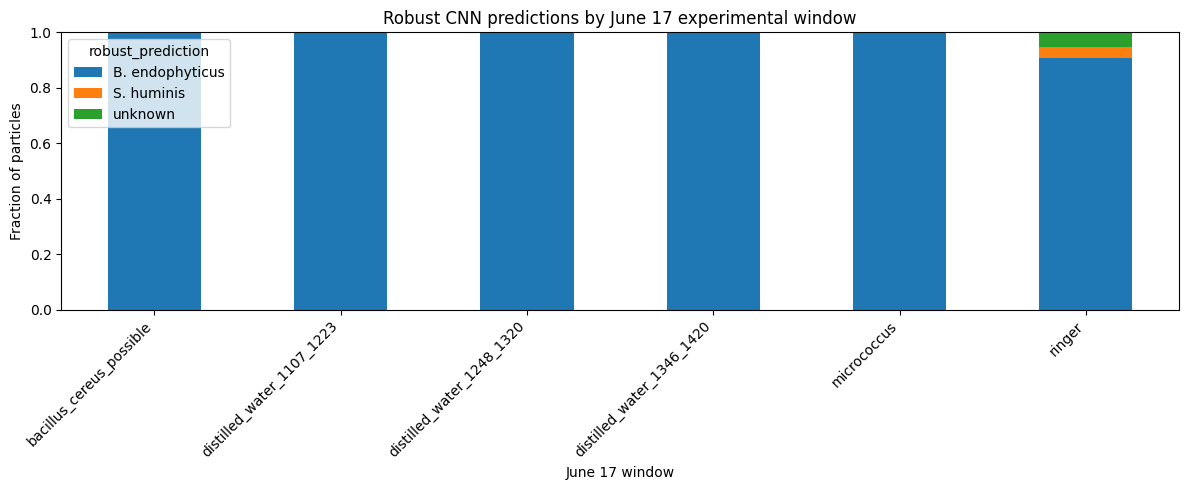

In [83]:
import matplotlib.pyplot as plt

plot_pivot = sample_counts.pivot_table(index="june17_window", columns="robust_prediction", values="fraction", fill_value=0)
ax = plot_pivot.plot(kind="bar", stacked=True, figsize=(12, 5))
ax.set_ylabel("Fraction of particles")
ax.set_xlabel("June 17 window")
ax.set_title("Robust CNN predictions by June 17 experimental window")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "june17_prediction_fractions.png", dpi=200)
plt.show()


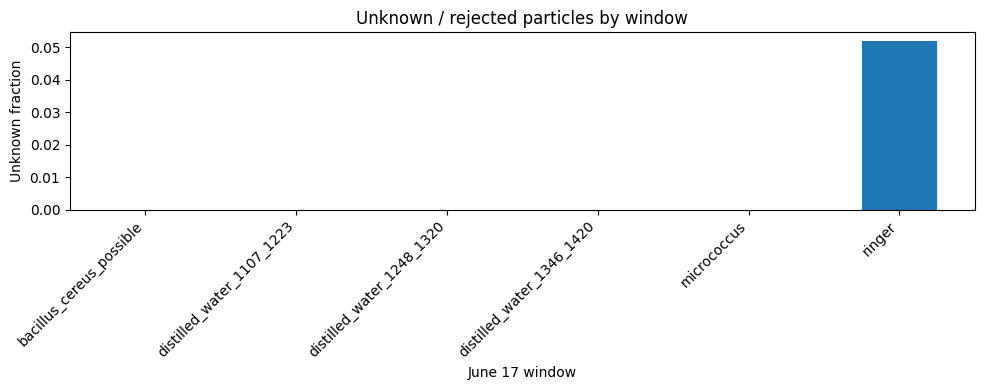

In [84]:
ax = sample_summary.set_index("june17_window")["unknown_fraction"].plot(kind="bar", figsize=(10, 4))
ax.set_ylabel("Unknown fraction")
ax.set_xlabel("June 17 window")
ax.set_title("Unknown / rejected particles by window")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "june17_unknown_fraction.png", dpi=200)
plt.show()


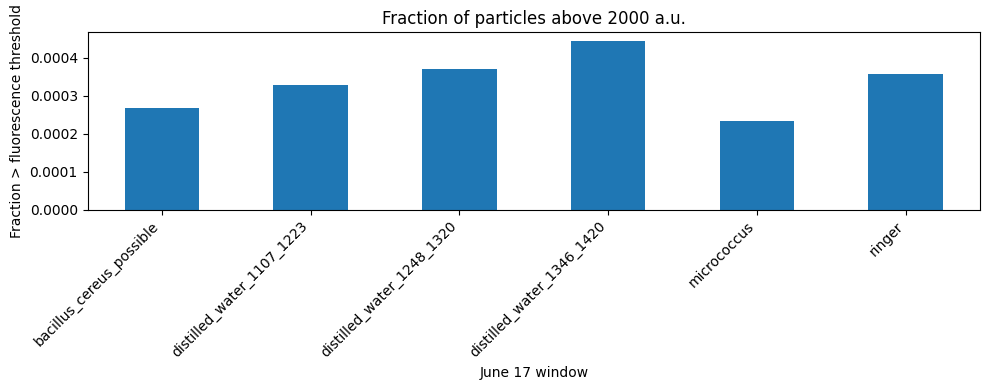

In [85]:
ax = threshold_summary.set_index("june17_window")["fraction_after_threshold"].plot(kind="bar", figsize=(10, 4))
ax.set_ylabel("Fraction > fluorescence threshold")
ax.set_xlabel("June 17 window")
ax.set_title(f"Fraction of particles above {FLUORESCENCE_THRESHOLD:.0f} a.u.")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "june17_fluorescence_threshold_fraction.png", dpi=200)
plt.show()


## 9. Modality ablation test


In [87]:
ABLATIONS = {
    "full": ["spectrometer", "lifetime", "scattering", "scalar"],
    "no_scattering": ["spectrometer", "lifetime", "scalar"],
    "lifetime_scalar": ["lifetime", "scalar"],
    "lifetime_only": ["lifetime"],
    "spectrometer_lifetime": ["spectrometer", "lifetime"],
}

rows = []
for ablation_name, modalities in ABLATIONS.items():
    ab_idx, ab_proba = predict_loader(model, loader, device)
    ab_rejected, ab_diag = apply_rejection(ab_proba, X_scalar_scaled, rejection_config, distance_reference)
    ab_labels = label_encoder.inverse_transform(ab_idx).astype(str)
    ab_labels = ab_labels.copy()
    ab_labels[ab_rejected] = UNKNOWN_LABEL

    tmp = filtered_df[["june17_window", "expected_sample"]].copy()
    tmp["prediction"] = ab_labels
    tmp["rejected_unknown"] = ab_rejected
    tmp["max_proba"] = ab_diag["max_proba"]
    tmp["entropy"] = ab_diag["entropy"]

    for (window, expected), group in tmp.groupby(["june17_window", "expected_sample"]):
        counts = group["prediction"].value_counts(normalize=True)
        rows.append({
            "ablation": ablation_name,
            "june17_window": window,
            "expected_sample": expected,
            "n_particles": len(group),
            "unknown_fraction": group["rejected_unknown"].mean(),
            "median_max_proba": group["max_proba"].median(),
            "mean_entropy": group["entropy"].mean(),
            "dominant_prediction": counts.index[0],
            "dominant_fraction": counts.iloc[0],
        })

ablation_summary = pd.DataFrame(rows)
ablation_summary.to_csv(OUTPUT_DIR / "june17_modality_ablation_summary.csv", index=False)
ablation_summary


AttributeError: 'dict' object has no attribute 'softmax_threshold'

## Interpretation guide

- Ringer/distilled water mostly predicted as bacteria with high confidence means the model still sees control artifacts as species-like.
- High unknown fraction in Ringer/distilled water means the robust rejection layer is doing its job.
- If `no_scattering` or `lifetime_scalar` looks more stable than `full`, scattering may be carrying saturation artifacts.
- If the fraction above 2000 a.u. is much higher than expected, the run likely has saturation or fluorescent background problems.


In [ ]:
print("Outputs written to:", OUTPUT_DIR)
for path in sorted(OUTPUT_DIR.glob("june17_*")):
    print("-", path)


Outputs written to: C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\june17_robust_cnn_test
- C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\june17_robust_cnn_test\june17_file_prediction_counts.csv
- C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\june17_robust_cnn_test\june17_file_qc_summary.csv
- C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\june17_robust_cnn_test\june17_fluorescence_threshold_fraction.png
- C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\june17_robust_cnn_test\june17_prediction_fraction_table.csv
- C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\june17_robust_cnn_test\june17_prediction_fractions.png
- C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif_thesis\results\june17_robust_cnn_test\june17_threshold_qc.csv
- C:\Users\chris\OneDrive\Documents\Universitat de Barcelona\lif